# K Nearest Neighbors Classifier

## Food Preference Classification

### Step 1: Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Step 2: Load Dataset

In [2]:
df = pd.read_csv(r"D:\4th Semester\Machine Learning by Sir  Abdul Aziz\daily_food_dataset.csv")
df.head()

,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.0,2.0,14.0,0.0,1.0,180.0,370,Breakfast,250
1,Whole Wheat Toast (1 slice),Grain,80,4.0,14.0,1.0,2.0,2.0,140.0,0,Breakfast,0
2,Coffee (black),Beverage,5,0.3,0.0,0.1,0.0,0.0,5.0,0,Breakfast,0
3,Banana,Fruit,105,1.3,27.0,0.4,3.1,14.0,1.0,0,Breakfast,0
4,Grilled Chicken Salad,Meal/Protein,350,30.0,10.0,20.0,5.0,4.0,400.0,80,Lunch,500


### Step 3: Data Preprocessing & EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Food_Item          651 non-null    str    
 1   Category           651 non-null    str    
 2   Calories (kcal)    651 non-null    int64  
 3   Protein (g)        651 non-null    float64
 4   Carbohydrates (g)  651 non-null    float64
 5   Fat (g)            651 non-null    float64
 6   Fiber (g)          651 non-null    float64
 7   Sugars (g)         651 non-null    float64
 8   Sodium (mg)        651 non-null    float64
 9   Cholesterol (mg)   651 non-null    int64  
 10  Meal_Type          651 non-null    str    
 11  Water_Intake (ml)  651 non-null    int64  
dtypes: float64(6), int64(3), str(3)
memory usage: 61.2 KB


In [4]:
# Checking Missing values
df.isnull().sum()

Food_Item            0
Category             0
Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Fiber (g)            0
Sugars (g)           0
Sodium (mg)          0
Cholesterol (mg)     0
Meal_Type            0
Water_Intake (ml)    0
dtype: int64

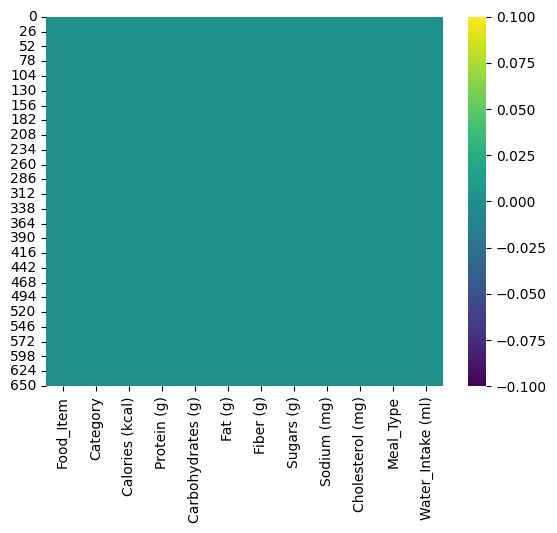

In [5]:
sns.heatmap(df.isnull(),cmap="viridis")
plt.show()

### Step 4: Encoding of Dataset

In [6]:
# Checking String type columns
df.select_dtypes(include="str").columns

Index(['Food_Item', 'Category', 'Meal_Type'], dtype='str')

In [7]:
df['Food_Item'].unique()

<StringArray>
[      'Scrambled Eggs (2 large)',    'Whole Wheat Toast (1 slice)',
                 'Coffee (black)',                         'Banana',
          'Grilled Chicken Salad',                          'Apple',
           'Salmon (4oz grilled)',          'Quinoa (1 cup cooked)',
       'Steamed Broccoli (1 cup)',     'Greek Yogurt (plain 1 cup)',
 ...
   'Turkish Coffee (1 small cup)',           'Cardamom (in coffee)',
       'Shish Tawook (2 skewers)',     'Garlic Sauce (Toum 1 tbsp)',
            'French Fries (side)',     'Pickled Cucumber (1/4 cup)',
      'Fattoush Salad (1.5 cups)', 'Fried Pita (1/2 pita in salad)',
       'Sumac (1/2 tsp dressing)',   'Pomegranate Molasses (1 tsp)']
Length: 593, dtype: str

In [8]:
# Apply Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Food_Item'] = le.fit_transform(df['Food_Item'])

In [9]:
df['Category'].unique()

<StringArray>
[       'Protein/Dairy',                'Grain',             'Beverage',
                'Fruit',         'Meal/Protein',         'Protein/Fish',
            'Vegetable',                'Dairy',                  'Nut',
       'Meal/Processed',           'Meal/Pasta',           'Supplement',
      'Grain/Processed',              ' 1 cup)',          'Meal/Legume',
      'Meal/Vegetarian',            'Meal/Fish',         'Protein/Meat',
        'Dairy/Dessert',              'Protein',  'Vegetable/Processed',
 'Supplement/Processed',               'Legume',              'Dessert',
            'Condiment',        'Beverage/Meal',   'Protein/Vegetarian',
       'Meal/Vegetable',            'Meal/Meat',  'Vegetable/Condiment',
         'Meal/Seafood',       'Beverage/Dairy',        'Grain/Dessert',
      'Snack/Processed',      'Condiment/Dairy',      'Protein/Seafood',
           'Meal/Grain',                 'Meal',   'Beverage/Dairy-Alt',
             ' yellow)',             

In [10]:
# Apply Label Encoding
df['Category'] = le.fit_transform(df['Category'])

In [11]:
df['Meal_Type'].unique()

<StringArray>
['Breakfast', 'Lunch', 'Dinner']
Length: 3, dtype: str

In [12]:
# Apply Label Encoding
df['Meal_Type'] = le.fit_transform(df['Meal_Type'])

In [13]:
df.head(8)

,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,487,36,180,12.0,2.0,14.0,0.0,1.0,180.0,370,0,250
1,589,16,80,4.0,14.0,1.0,2.0,2.0,140.0,0,0,0
2,150,5,5,0.3,0.0,0.1,0.0,0.0,5.0,0,0,0
3,31,15,105,1.3,27.0,0.4,3.1,14.0,1.0,0,0,0
4,249,28,350,30.0,10.0,20.0,5.0,4.0,400.0,80,2,500
5,11,15,95,0.5,25.0,0.3,4.4,19.0,2.0,0,2,0
6,475,37,230,25.0,0.0,14.0,0.0,0.0,60.0,60,1,250
7,443,16,222,8.0,39.0,3.6,5.0,1.0,13.0,0,1,0


### Step 5: Normalization

In [14]:
# Balance the Features for better results
from sklearn.preprocessing import MinMaxScaler
m = MinMaxScaler(feature_range=(0,1))
x = df.drop(columns=['Meal_Type'])
for i in x.columns:
   df[i] = m.fit_transform(df[[i]])

In [15]:
df.head()

,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,0.822635,0.72,0.264706,0.0600,0.028571,0.3500,0.000000,0.016667,0.113924,0.822222,0,0.5
1,0.994932,0.32,0.117647,0.0200,0.200000,0.0250,0.142857,0.033333,0.088608,0.000000,0,0.0
2,0.253378,0.10,0.007353,0.0015,0.000000,0.0025,0.000000,0.000000,0.003165,0.000000,0,0.0
3,0.052365,0.30,0.154412,0.0065,0.385714,0.0100,0.221429,0.233333,0.000633,0.000000,0,0.0
4,0.420608,0.56,0.514706,0.1500,0.142857,0.5000,0.357143,0.066667,0.253165,0.177778,2,1.0


### Visualization

C:\Users\Computer.com\AppData\Local\Temp\ipykernel_10904\3476438786.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 2000x3500 with 0 Axes>

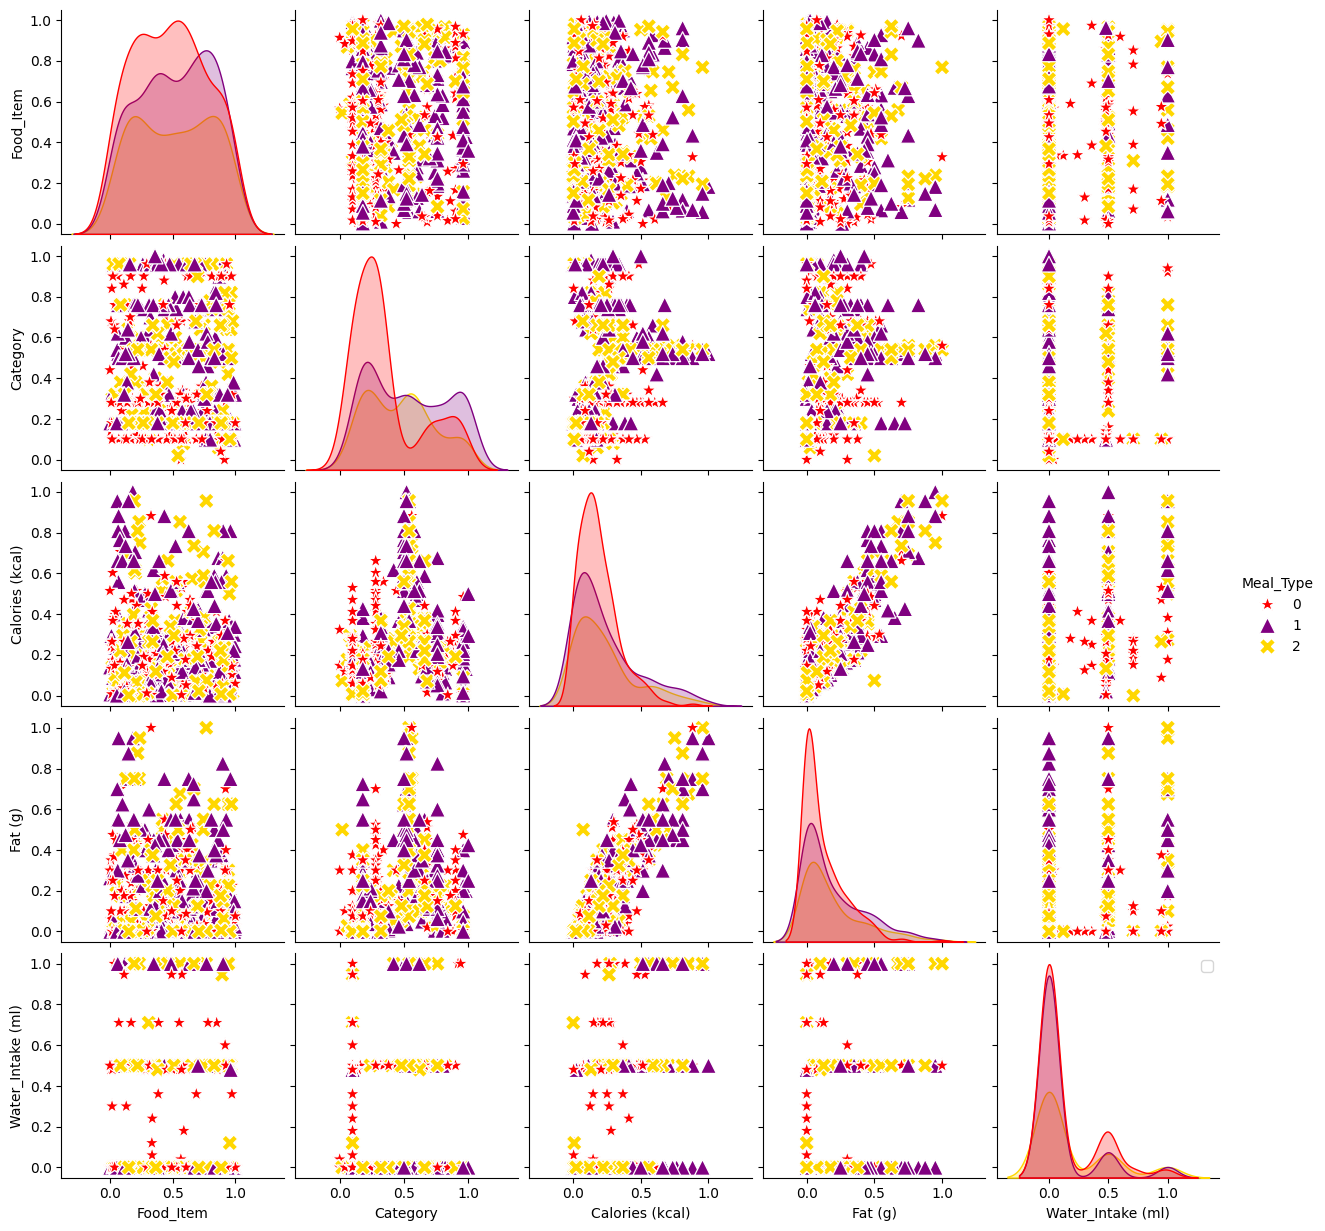

In [16]:
# pair plot
plt.figure(figsize=(20,35))
col =df[ ['Food_Item','Category','Calories (kcal)','Fat (g)','Water_Intake (ml)','Meal_Type']]
sns.pairplot(data=col, hue="Meal_Type", markers=['*', '^', 'X'],palette=['red','purple','gold'],plot_kws={'s':130})
plt.legend()
plt.show()

### Step 6: Splitting of Data into Training & Testing

In [17]:
X =df.drop(columns=['Meal_Type'])
y = df['Meal_Type']
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Step 7: Apply Model

In [18]:
# Apply the KNN model
from sklearn.neighbors import KNeighborsClassifier
k = KNeighborsClassifier(n_neighbors=7, metric='minkowski',p=2)
k.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Step 8: Prediction

In [19]:
y_pred = k.predict(X_test)
pd.DataFrame({"Actual":y_test, "Predicted":y_pred})

,Actual,Predicted
638,0,0
264,0,0
259,0,0
495,0,0
72,1,1
...,...,...
512,1,1
451,1,1
299,1,1
526,1,2


In [20]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)*100

67.17557251908397

### Step 9: Visualization

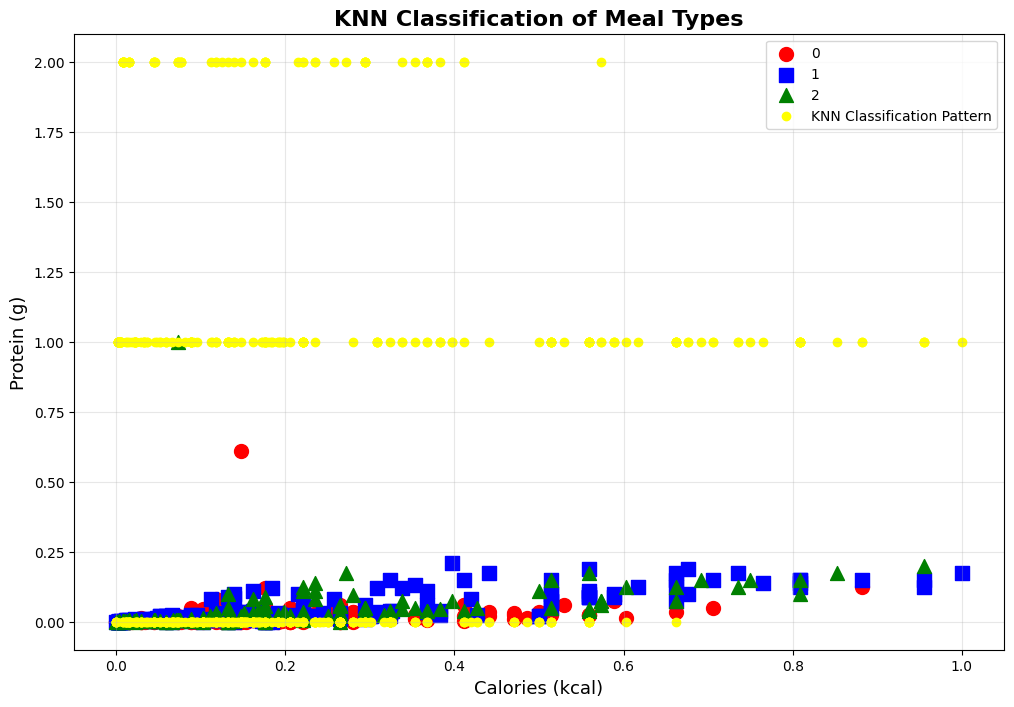

In [24]:
plt.figure(figsize=(12,8))

# Only two features
X_vis = X_train[['Calories (kcal)','Protein (g)']]

# Train again on only 2 features
k.fit(X_vis, y_train)

# Predictions on training data
Z = k.predict(X_vis)

# Scatter Points with Different Markers
for meal, marker, color in zip(np.unique(Z),['o','s','^'],['red','blue','green']):
    plt.scatter(X_vis[y_train == meal]['Calories (kcal)'],X_vis[y_train == meal]['Protein (g)'],marker=marker,color=color,s=100,label=meal)

# Simple lines to show separation feeling
plt.scatter(X_vis['Calories (kcal)'],Z,color='yellow',linewidth=1,label='KNN Classification Pattern')

# Labels
plt.title("KNN Classification of Meal Types", fontsize=16, fontweight='bold')
plt.xlabel("Calories (kcal)", fontsize=13)
plt.ylabel("Protein (g)", fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Model is only 67% train that's why there is no proper classification of "Meal_Type", we can see in the above graph.